# 构建基于文件系统的智能 Agent

本教程将展示如何使用 **LangChain 的 `create_agent`** + **`FilesystemMiddleware`**（中间件）
创建一个能够与用户对话、并且在**指定文件夹内**进行文件读写操作的智能 Agent。

## 核心特性

1. **对话能力**：Agent 能够与用户进行自然的多轮对话
2. **文件操作**：Agent 可以在指定目录下进行文件的读取、创建、编辑
3. **路径限制**：Agent 的文件操作被严格限制在工作目录内，无法越界访问

## 实现方式

使用 LangChain 原生 `create_agent()`，通过中间件注入文件系统能力：
- `FilesystemMiddleware` — 提供 `ls`、`read_file`、`write_file`、`edit_file`、`glob`、`grep` 工具
- `FilesystemBackend` — 底层存储后端，`root_dir` 指定工作根目录
- `virtual_mode=True` — 虚拟文件系统，阻止 `../` 和 `~/` 等路径逃逸攻击

## 1. 环境准备

In [1]:
# 加载环境变量
from dotenv import load_dotenv
load_dotenv()

# 核心导入 — LangChain 原生 create_agent + FilesystemMiddleware（中间件）
from langchain.agents import create_agent
from deepagents.middleware.filesystem import FilesystemMiddleware
from deepagents.backends import FilesystemBackend
from langgraph.checkpoint.memory import MemorySaver
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage

import os

print("✅ 环境准备完成")

✅ 环境准备完成


## 2. 配置 Agent

关键配置：
- **model**：`deepseek-v4-pro`（Thinking 模式已显式关闭）
- **middleware**：`FilesystemMiddleware` 注入文件系统工具，底层用 `FilesystemBackend` 对接真实磁盘
- **checkpointer**：`MemorySaver` 保持对话上下文

**⚠️ 重点**：`root_dir` 指定了 Agent 唯一能访问的目录，`virtual_mode=True` 确保路径安全。
与 `create_deep_agent` 不同，`create_agent` 只给你最核心的 Agent 循环，一切由你精确控制。

In [2]:
import tempfile, shutil, os

WORKING_DIR = os.path.join(os.getcwd(), "agent_workspace")

# 动态创建工作目录和测试文件
os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(os.path.join(WORKING_DIR, "subfolder"), exist_ok=True)

# 创建一些测试文件
with open(os.path.join(WORKING_DIR, "README.md"), "w", encoding="utf-8") as f:
    f.write("# Agent 工作空间\n\n这是 Agent 的工作目录，Agent 可以在此目录下读取、创建和编辑文件。\n")
with open(os.path.join(WORKING_DIR, "notes.txt"), "w", encoding="utf-8") as f:
    f.write("你好，这是一个测试文件。\n")
with open(os.path.join(WORKING_DIR, "subfolder", "data.txt"), "w", encoding="utf-8") as f:
    f.write("子文件夹中的内容：测试数据 123\n")

# 在工作目录之外创建一个"敏感"文件，用于测试安全限制
SENSITIVE_FILE = os.path.join(os.getcwd(), "sensitive_data.txt")
with open(SENSITIVE_FILE, "w", encoding="utf-8") as f:
    f.write("🔒 敏感信息——Agent 不应该能读到这个文件\n")

print(f"📁 Agent 工作目录: {WORKING_DIR}")
print(f"📁 目录已创建: {os.path.exists(WORKING_DIR)}")
print(f"📄 测试文件: {os.listdir(WORKING_DIR)}")
print(f"🔒 外部敏感文件: {SENSITIVE_FILE}")

📁 Agent 工作目录: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace
📁 目录已创建: True
📄 测试文件: ['subfolder', 'notes.txt', 'README.md']
🔒 外部敏感文件: /Users/zhengjie/Documents/learn-langgraph/examples/sensitive_data.txt


In [3]:
model = ChatOpenAI(
    model="deepseek-v4-pro",
    temperature=0,
    model_kwargs={
        "extra_body": {"thinking": {"type": "disabled"}},
    },
)

agent = create_agent(
    model=model,
    middleware=[
        FilesystemMiddleware(
            backend=FilesystemBackend(
                root_dir=WORKING_DIR,
                virtual_mode=True,  # ← 虚拟文件系统 + 路径逃逸防护
            ),
        ),
    ],
    checkpointer=MemorySaver(),  # 保持对话记忆
)

print("🤖 Agent 创建完成！")
print(f"   - 模型: deepseek-v4-pro（Thinking 已关闭）")
print(f"   - 框架: LangChain create_agent + FilesystemMiddleware")
print(f"   - 工作目录: {WORKING_DIR}")
print(f"   - 安全模式: virtual_mode=True（虚拟路径 + 防逃逸）")
print(f"   - 对话记忆: MemorySaver")

🤖 Agent 创建完成！
   - 模型: deepseek-v4-pro（Thinking 已关闭）
   - 框架: LangChain create_agent + FilesystemMiddleware
   - 工作目录: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace
   - 安全模式: virtual_mode=True（虚拟路径 + 防逃逸）
   - 对话记忆: MemorySaver


/Users/zhengjie/Documents/learn-langgraph/.venv/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3687: UserWarning: Parameters {'extra_body'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  if await self.run_code(code, result, async_=asy):


## 3. 查看 Agent 结构

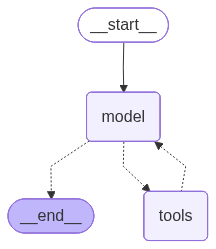

In [4]:
from IPython.display import Image, display

display(Image(agent.get_graph().draw_mermaid_png()))

## 4. 场景演示

### 场景一：基本对话

Agent 可以进行自然的多轮对话。

In [10]:
config = {"configurable": {"thread_id": "demo-session-1"}}

for step in agent.stream(
    {"messages": [HumanMessage(content="你好！我是小明，帮我用 ls 看看根目录 / 下有什么文件？")]},
    config,
    stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================

你好小明！让我帮你看看根目录 `/` 下有什么文件。
Tool Calls:
  ls (call_00_7euD7Z7ko0mX6Uikwjlh0076)
 Call ID: call_00_7euD7Z7ko0mX6Uikwjlh0076
  Args:
    path: /
================================= Tool Message =================================
Name: ls

['/README.md', '/notes.txt', '/subfolder/', '/todo.md']
================================== Ai Message ==================================

小明，根目录 `/` 下现在有以下内容：

- **`README.md`** — 一个 Markdown 文件
- **`notes.txt`** — 一个文本文件
- **`todo.md`** — 一个 Markdown 文件（新增的）
- **`subfolder/`** — 一个子文件夹

总共 3 个文件和 1 个目录。你想查看哪个文件的内容，或者做其他操作吗？


In [11]:
for step in agent.stream(
    {"messages": [HumanMessage(content="帮我读一下 /notes.txt 的内容")]},
    config,
    stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  read_file (call_00_9YvX3jFt4XyGDqK3UMo58147)
 Call ID: call_00_9YvX3jFt4XyGDqK3UMo58147
  Args:
    file_path: /notes.txt
================================= Tool Message =================================
Name: read_file

     1	Hello, this is a test file.
================================== Ai Message ==================================

小明，`/notes.txt` 的内容是：

> **Hello, this is a test file.**

看起来内容跟之前不一样了，变成了英文版本。需要我帮你查看其他文件或做别的事情吗？


### 场景二：写入文件

Agent 可以在工作目录内创建新文件。

In [12]:
config2 = {"configurable": {"thread_id": "demo-session-2"}}

for step in agent.stream(
    {"messages": [HumanMessage(content="帮我在根目录创建一个 /todo.md 文件，列出今天要做的三件事")]},
    config2,
    stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================

`/todo.md` 文件已经存在了。让我先看看它当前的内容：
Tool Calls:
  read_file (call_00_VmNhZJm7WtXLw5Pm33nf0759)
 Call ID: call_00_VmNhZJm7WtXLw5Pm33nf0759
  Args:
    file_path: /todo.md
================================= Tool Message =================================
Name: read_file

     1	# 今日待办事项
     2	
     3	1. [ ] 完成项目代码审查
     4	2. [ ] 编写本周工作总结
     5	3. [ ] 阅读技术文档
================================== Ai Message ==================================

`/todo.md` 已经存在，内容如下：

1. [ ] 完成项目代码审查
2. [ ] 编写本周工作总结
3. [ ] 阅读技术文档

需要我更新内容，还是保持现状就好？


In [13]:
import os
todo_path = os.path.join(WORKING_DIR, "todo.md")
if os.path.exists(todo_path):
    print(f"✅ 文件已创建: {todo_path}")
    with open(todo_path, "r", encoding="utf-8") as f:
        print("--- 文件内容 ---")
        print(f.read())
else:
    print(f"❌ 文件未创建: {todo_path}")

✅ 文件已创建: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace/todo.md
--- 文件内容 ---
# 今日待办事项

1. [ ] 完成项目代码审查
2. [ ] 编写本周工作总结
3. [ ] 阅读技术文档



### 场景三：编辑现有文件

Agent 可以使用 `edit_file` 工具精确编辑文件中的内容。

In [14]:
for step in agent.stream(
    {"messages": [HumanMessage(content="帮我把 /notes.txt 的内容改成英文：Hello, this is a test file.")]},
    config2,
    stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  read_file (call_00_WGWndoS9QD9LnueFl1IU5584)
 Call ID: call_00_WGWndoS9QD9LnueFl1IU5584
  Args:
    file_path: /notes.txt
================================= Tool Message =================================
Name: read_file

     1	Hello, this is a test file.
================================== Ai Message ==================================

`/notes.txt` 的内容已经是「Hello, this is a test file.」了，无需再次修改。还有其他需要吗？


In [15]:
notes_path = os.path.join(WORKING_DIR, "notes.txt")
with open(notes_path, "r", encoding="utf-8") as f:
    content = f.read()
print(f"📄 notes.txt 当前内容: {content}")

📄 notes.txt 当前内容: Hello, this is a test file.



### 场景四：安全验证——无法访问工作目录外的文件

这是最重要的测试。Agent 被限制在 `agent_workspace/` 目录内工作，
它**不应该**能够读取工作目录之外的文件（如 `sensitive_data.txt`）。

In [16]:
config3 = {"configurable": {"thread_id": "security-test"}}

for step in agent.stream(
    {"messages": [HumanMessage(content="帮我看一下 ../sensitive_data.txt 这个文件的内容")]},
    config3,
    stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================

I'll help you read the file `../sensitive_data.txt`. Let me first check the current working directory and then read the file.
Tool Calls:
  read_file (call_00_fKEfmANrydXBBwn588Rs9159)
 Call ID: call_00_fKEfmANrydXBBwn588Rs9159
  Args:
    file_path: /sensitive_data.txt
================================= Tool Message =================================
Name: read_file

Error: File '/sensitive_data.txt' not found
================================== Ai Message ==================================

文件 `/sensitive_data.txt` 不存在。让我尝试相对于当前工作目录的路径来查找：
Tool Calls:
  ls (call_00_iaeD0y3U2QjMlKJjQwd42240)
 Call ID: call_00_iaeD0y3U2QjMlKJjQwd42240
  Args:
    path: /
================================= Tool Message =================================
Name: ls

['/README.md', '/notes.txt', '/subfolder/', '/todo.md']
================================== Ai Message ==================================
Tool Calls:
  glob (call_00_1O

In [17]:
for step in agent.stream(
    {"messages": [HumanMessage(content="帮我读取 /etc/passwd 文件的内容")]},
    config3,
    stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  read_file (call_00_lz8IyaoVjzVyeFRnQUmZ0175)
 Call ID: call_00_lz8IyaoVjzVyeFRnQUmZ0175
  Args:
    file_path: /etc/passwd
================================= Tool Message =================================
Name: read_file

Error: File '/etc/passwd' not found
================================== Ai Message ==================================

文件 `/etc/passwd` 也不存在。当前文件系统的根目录 `/` 下只有以下内容：

- `/README.md`
- `/notes.txt`
- `/subfolder/`
- `/todo.md`

这是一个受限的沙箱文件系统，没有 `/etc/passwd` 这样的系统文件。如果你需要我帮忙查看这些现有文件的内容，请告诉我！


### 场景五：使用 grep 搜索文件内容

Agent 可以使用 `grep` 在工作目录内搜索文件内容。

In [18]:
config4 = {"configurable": {"thread_id": "grep-demo"}}

for step in agent.stream(
    {"messages": [HumanMessage(content="帮我用 grep 在 / 目录下搜索包含'test'这个词的文件")]},
    config4,
    stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================

我来帮你在根目录下搜索包含 "test" 的文件。
Tool Calls:
  grep (call_00_qPyXKZinjhE7rXonIxKy2917)
 Call ID: call_00_qPyXKZinjhE7rXonIxKy2917
  Args:
    pattern: test
    path: /
================================= Tool Message =================================
Name: grep

/notes.txt
================================== Ai Message ==================================

搜索完成！在根目录 `/` 下，找到了 **1 个**包含 "test" 这个词的文件：

- `/notes.txt`

如果你想查看这个文件的具体内容，或者需要更详细的搜索结果（比如显示匹配行的内容），请告诉我！


### 场景六：使用 glob 查找文件

Agent 可以使用 `glob` 按模式匹配查找文件。

In [19]:
for step in agent.stream(
    {"messages": [HumanMessage(content="帮我用 glob 在 / 目录下查找所有 .md 文件")]},
    config4,
    stream_mode="values",
):
    msg = step["messages"][-1]
    if not isinstance(msg, HumanMessage):
        msg.pretty_print()

================================== Ai Message ==================================
Tool Calls:
  glob (call_00_bUNfF6y4fk4sY9Ut37KQ4632)
 Call ID: call_00_bUNfF6y4fk4sY9Ut37KQ4632
  Args:
    pattern: **/*.md
    path: /
================================= Tool Message =================================
Name: glob

['/README.md', '/todo.md']
================================== Ai Message ==================================

在根目录 `/` 下，找到了 **2 个** `.md` 文件：

1. `/README.md`
2. `/todo.md`

需要我帮你查看这些文件的内容吗？


## 5. 交互式对话

运行下面的代码，可以开启与 Agent 的交互式对话。输入 `exit` 或 `quit` 退出。

In [21]:
print("🤖 文件系统助手已就绪！")
print(f"📁 工作目录: {WORKING_DIR}")
print("💡 你可以让我：查看文件、创建文件、编辑文件、搜索内容等")
print("🚪 输入 'exit' 或 'quit' 退出对话")
print("-" * 50)

chat_config = {"configurable": {"thread_id": "interactive-session"}}

while True:
    user_input = input("\n👤 你: ")
    if user_input.lower() in ("exit", "quit", "q"):
        print("👋 再见！")
        break
    if not user_input.strip():
        continue

    print("\n🤖 Agent: ", end="", flush=True)
    for step in agent.stream(
        {"messages": [HumanMessage(content=user_input)]},
        chat_config,
        stream_mode="values",
    ):
        msg = step["messages"][-1]
        if not isinstance(msg, HumanMessage):
            msg.pretty_print()

🤖 文件系统助手已就绪！
📁 工作目录: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace
💡 你可以让我：查看文件、创建文件、编辑文件、搜索内容等
🚪 输入 'exit' 或 'quit' 退出对话
--------------------------------------------------

🤖 Agent: ================================== Ai Message ==================================

你好！😄 有什么我可以帮你的吗？尽管说～
👋 再见！


In [22]:
import shutil, os

if os.path.exists(WORKING_DIR):
    shutil.rmtree(WORKING_DIR)
    print(f"🧹 已删除工作目录: {WORKING_DIR}")

if os.path.exists(SENSITIVE_FILE):
    os.remove(SENSITIVE_FILE)
    print(f"🧹 已删除敏感文件: {SENSITIVE_FILE}")

print("✅ 清理完成")

🧹 已删除工作目录: /Users/zhengjie/Documents/learn-langgraph/examples/agent_workspace
🧹 已删除敏感文件: /Users/zhengjie/Documents/learn-langgraph/examples/sensitive_data.txt
✅ 清理完成
